In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

root_dir = os.path.normpath(os.getcwd()+'/..' * 3)
package_dir = os.path.join(root_dir, 'src')
sys.path.append(package_dir)

from modules.data.datasets import Dataset #DeepSTABp_Dataset

ratio = [8,1,1]

edge_policy = '1CONT'
thresholds = {
    'contact': '12',
    'codir': edge_policy,
    'coord': edge_policy,
    'deform': edge_policy,
}


In [2]:

pdb_assembly_ids = np.loadtxt(
    f'{package_dir}/data_curation/20250704-1 homo-multimer dataset (from scratch)/stats/OUT-6.entries_id.txt',
    dtype=np.str_
)
annotations = np.loadtxt(
    f'{package_dir}/data_curation/20250704-1 homo-multimer dataset (from scratch)/stats/OUT-6.labels_for_prediction.csv',
    delimiter=',',
    dtype=np.int32
)
assert pdb_assembly_ids.shape[0] == annotations.shape[0]

print(pdb_assembly_ids.shape)
print(annotations.shape)


(11043,)
(11043, 20)


In [3]:

dataset_multimer = Dataset(
    pdb_assembly_ids,
    annotations=annotations,
    version='v0',
    sequence_embedding='ProtTrans',
    enm_type='anm',
    use_monomers=False,
    thresholds=thresholds,
    merge_edge_types=False,
    time_limit=60,
    transform=None,
    # device=df_device,
    entries_should_be_ready=False,
    rebuild=False
)
print()

dataset_monomer = Dataset(
    pdb_assembly_ids,
    annotations=annotations,
    version='v0',
    sequence_embedding='ProtTrans',
    enm_type='anm',
    use_monomers=True,
    thresholds=thresholds,
    merge_edge_types=False,
    time_limit=60,
    transform=None,
    # device=df_device,
    entries_should_be_ready=False,
    rebuild=False
)
print()

np.savetxt(
    'multimer-identifiers.txt',
    dataset_multimer.processed_assemblies,
    fmt='%s'
)
print(f'Multimer dataset size: {len(dataset_multimer.processed_assemblies)}')
np.savetxt(
    'monomer-identifiers.txt',
    dataset_monomer.processed_assemblies,
    fmt='%s'
)
print(f'Monomer dataset size: {len(dataset_monomer.processed_assemblies)}')

intersection_identifiers = np.intersect1d(
    dataset_multimer.processed_assemblies,
    dataset_monomer.processed_assemblies
)
np.savetxt(
    'intersection-identifiers.txt',
    intersection_identifiers,
    fmt='%s'
)
print(f'Intersection size: {len(intersection_identifiers)}')


Processing...
ANM 9MUA-1      : 100%|##########| 11043/11043 [00:02<00:00, 4659.95it/s]


 -> Accessions with NMA results       : 11028


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Graphs 7CW5-1      :  92%|#########1| 10106/11028 [00:01<00:00, 5062.05it/s]

 -> 2FMD-1 contains non-standard amino acids (B), discarding.


Graphs 9MUA-1      : 100%|##########| 11028/11028 [00:02<00:00, 5392.49it/s]
Done!


...

 -> Accessions with NMA results       : 10990


Graphs 7X78-1      :  91%|######### | 9987/10990 [00:01<00:00, 5367.85it/s]

 -> 2FMD-1 contains non-standard amino acids (B), discarding.


Graphs 9MUA-1      : 100%|##########| 10990/10990 [00:02<00:00, 5400.95it/s]
Done!


 -> Assemblies successfully processed : 10989
 -> Number of unique accessions : 10989
 -> Number of labels to predict : 20
Dataset instantiation complete.

Multimer dataset size: 11027
Monomer dataset size: 10989
Intersection size: 10984


In [4]:
# get annotations of intersection

idx_intersection = np.isin(pdb_assembly_ids, intersection_identifiers)
annotations_intersection = annotations[idx_intersection]
np.savetxt(
    'intersection-annotations.csv',
    annotations_intersection,
    delimiter=',',
    fmt='%d'
)

assert annotations_intersection.shape[0] == intersection_identifiers.shape[0]
assert (np.sum(annotations_intersection, axis=0) > 0).all()


In [5]:

n_entries = intersection_identifiers.shape[0]
n_GO_terms = annotations_intersection.shape[1]

for try_idx in range(10):

    indices = np.random.permutation(n_entries)

    train_indices = indices[:int(n_entries*ratio[0]/sum(ratio))]
    valid_indices = indices[int(n_entries*ratio[0]/sum(ratio)):int(n_entries*(ratio[0]+ratio[1])/sum(ratio))]
    test_indices = indices[int(n_entries*(ratio[0]+ratio[1])/sum(ratio)):]

    # ensure that all sets have at least one positive sample for each GO term
    if (
        annotations_intersection[train_indices].sum(axis=0) != 0
    ).all() and (
        annotations_intersection[valid_indices].sum(axis=0) != 0
    ).all() and (
        annotations_intersection[test_indices].sum(axis=0) != 0
    ).all():
        print(f'Successful data split! (try: {try_idx})')
        print(train_indices.shape, train_indices)
        print(valid_indices.shape, valid_indices)
        print(test_indices.shape, test_indices)
        break
    elif try_idx == 9:
        print('Failed to split data with at least one positive sample for each GO term in each set.')



Successful data split! (try: 0)
(8787,) [ 8896  4394  2850 ...  2126  4557 10676]
(1098,) [1323 2408 3326 ... 9602 4475 8806]
(1099,) [3920 1066 1164 ... 2587  702 7132]


In [6]:

np.savetxt(
    'train_identifiers.txt',
    intersection_identifiers[train_indices],
    fmt='%s'
)
np.savetxt(
    'train_annotations.csv',
    annotations[train_indices].astype(np.int16),
    fmt='%d',
    delimiter=','
)

np.savetxt(
    'valid_identifiers.txt',
    intersection_identifiers[valid_indices],
    fmt='%s'
)
np.savetxt(
    'valid_annotations.csv',
    annotations[valid_indices].astype(np.int16),
    fmt='%d',
    delimiter=','
)

np.savetxt(
    'test_identifiers.txt',
    intersection_identifiers[test_indices],
    fmt='%s'
)
np.savetxt(
    'test_annotations.csv',
    annotations[test_indices].astype(np.int16),
    fmt='%d',
    delimiter=','
)


/tmp/ipykernel_864989/3336578411.py:1: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  multimericity_info = np.loadtxt(
/tmp/ipykernel_864989/3336578411.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seq_len.append(int(sequence_info[sequence_info[:,0]==assembly_id,1]))
/tmp/ipykernel_864989/3336578411.py:23: DeprecationWarning: Conversion of an array with ndim > 0 t

7985


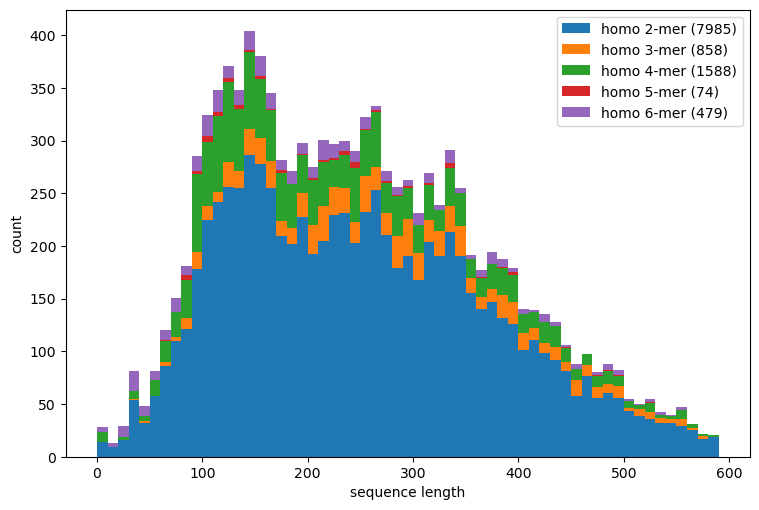

In [7]:

multimericity_info = np.loadtxt(
    f'{package_dir}/data_curation/20250704-1 homo-multimer dataset (from scratch)/stats/OUT-5.all_information-sim_0.95-PDB_ready.csv',
    usecols=(0,3),
    delimiter=',',
    dtype=np.str_
)

with open(f'{package_dir}/data_curation/20250704-1 homo-multimer dataset (from scratch)/stats/OUT-5.all_sequences-sim_0.95-PDB_ready.fasta', 'r') as f:
    file_content = [l.replace('\n', '') for l in f.readlines()]

sequence_info = []
for line in file_content:
    if line.startswith('>'):
        assembly_id = line.split(',')[0][1:]
    else:
        sequence_info.append((assembly_id, len(line)))
sequence_info = np.array(sequence_info)

seq_len = []
multimericity = []
for assembly_id in intersection_identifiers:
    seq_len.append(int(sequence_info[sequence_info[:,0]==assembly_id,1]))
    multimericity.append(int(multimericity_info[multimericity_info[:,0]==assembly_id,1]))
seq_len = np.array(seq_len)
multimericity = np.array(multimericity)

lengths_by_multimericity = []
for m in np.unique(multimericity):
    lengths_by_multimericity.append(seq_len[multimericity==m])

print(len(lengths_by_multimericity[0]))




### Data count

# PLOT
fig, ax = plt.subplots(figsize=(7.48, 7.48/3*2), layout='compressed')
ax.hist(
    lengths_by_multimericity,
    stacked=True,
    label=[
        f'homo {m}-mer ({len(lengths_by_multimericity[m_idx])})'
        for m_idx, m in enumerate(np.unique(multimericity))
    ],
    # edgecolor='white',
    bins=np.arange(60)*10
)
ax.set_xlabel('sequence length')
ax.set_ylabel('count')
# ax.set_xlim(0,600)
ax.legend()

plt.savefig(
    'seq length.png',
    dpi=300
)
plt.show()
plt.close()



[4596 4053 2984 2956 2207 1902 1895 1781 1634 1223 1223 1158 1138 1137
 1018  931  890  842  812  785]


/tmp/ipykernel_864989/946145320.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seq_len.append(int(sequence_info[sequence_info[:,0]==assembly_id,1]))
/tmp/ipykernel_864989/946145320.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  multimericity.append(int(multimericity_info[multimericity_info[:,0]==assembly_id,1]))


[588 526 388 383 281 251 251 232 218 156 163 151 168 152 135 122 116 110
 106 104]
[582 510 386 382 255 215 214 216 181 145 135 122 128 125 103  96  90  86
  80 101]


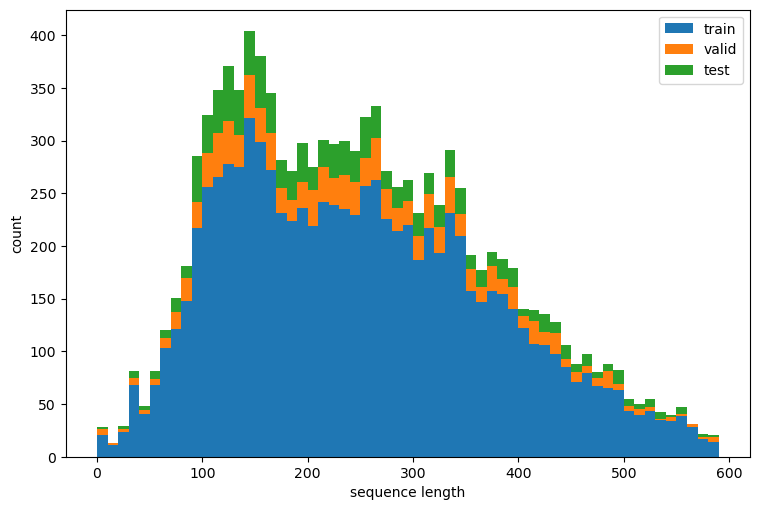

In [8]:

lengths_by_multimericity = []

for set_type in ['train', 'valid', 'test']:

    identifiers = np.loadtxt(
        f'{set_type}_identifiers.txt',
        dtype=np.str_,
    )

    annotations = np.loadtxt(
        f'{set_type}_annotations.csv',
        delimiter=',',
        dtype=np.bool_
    )
    print(np.sum(annotations, axis=0))

    sequence_info = []
    for line in file_content:
        if line.startswith('>'):
            assembly_id = line.split(',')[0][1:]
        else:
            sequence_info.append((assembly_id, len(line)))
    sequence_info = np.array(sequence_info)

    seq_len = []
    multimericity = []
    for assembly_id in identifiers:
        seq_len.append(int(sequence_info[sequence_info[:,0]==assembly_id,1]))
        multimericity.append(int(multimericity_info[multimericity_info[:,0]==assembly_id,1]))
    seq_len = np.array(seq_len)
    multimericity = np.array(multimericity)

    # for m in np.unique(multimericity):
    #     lengths_by_set_type.append(seq_len[multimericity==m])

    # print(len(lengths_by_set_type[0]))

    lengths_by_multimericity.append(seq_len)

# PLOT
fig, ax = plt.subplots(figsize=(7.48, 7.48/3*2), layout='compressed')
ax.hist(
    lengths_by_multimericity,
    stacked=True,
    label=['train', 'valid', 'test'],
    # edgecolor='white',
    bins=np.arange(60)*10
)
ax.set_xlabel('sequence length')
ax.set_ylabel('count')
# ax.set_xlim(0,600)
ax.legend()

plt.savefig(
    'seq length - data split.png',
    dpi=300
)
plt.show()
plt.close()

